# Uber NYC Data Analysis

## Business Objective
Analyze Uber trip activity in New York City from April to September 2014
to identify demand patterns across time, day, location, and Uber base.

#### 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
#One way Loading
files = os.listdir("../Data")
print(files)

['uber-raw-data-apr14.csv', 'uber-raw-data-aug14.csv', 'uber-raw-data-jul14.csv', 'uber-raw-data-jun14.csv', 'uber-raw-data-may14.csv', 'uber-raw-data-sep14.csv']


In [7]:
#Loop way loading 
for files in files:
    if files.endswith("csv"):
        print(files)
    

uber-raw-data-apr14.csv
uber-raw-data-aug14.csv
uber-raw-data-jul14.csv
uber-raw-data-jun14.csv
uber-raw-data-may14.csv
uber-raw-data-sep14.csv


In [11]:
path = "../Data"
files = [
    "uber-raw-data-apr14.csv",
    "uber-raw-data-may14.csv",
    "uber-raw-data-jun14.csv",
    "uber-raw-data-jul14.csv",
    "uber-raw-data-aug14.csv",
    "uber-raw-data-sep14.csv"
]
data = []
for file in files:
    df = pd.read_csv(os.path.join(path,file))
    data.append(df)

#### Combine everything

In [12]:
merged_df = pd.concat(data, ignore_index = True)
print(merged_df)

                  Date/Time      Lat      Lon    Base
0          4/1/2014 0:11:00  40.7690 -73.9549  B02512
1          4/1/2014 0:17:00  40.7267 -74.0345  B02512
2          4/1/2014 0:21:00  40.7316 -73.9873  B02512
3          4/1/2014 0:28:00  40.7588 -73.9776  B02512
4          4/1/2014 0:33:00  40.7594 -73.9722  B02512
...                     ...      ...      ...     ...
4534322  9/30/2014 22:57:00  40.7668 -73.9845  B02764
4534323  9/30/2014 22:57:00  40.6911 -74.1773  B02764
4534324  9/30/2014 22:58:00  40.8519 -73.9319  B02764
4534325  9/30/2014 22:58:00  40.7081 -74.0066  B02764
4534326  9/30/2014 22:58:00  40.7140 -73.9496  B02764

[4534327 rows x 4 columns]


### Understanding the data 

In [13]:
#Top 5 rows
merged_df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [14]:
#Last 5 rows
merged_df.tail()

,Date/Time,Lat,Lon,Base
4534322,9/30/2014 22:57:00,40.7668,-73.9845,B02764
4534323,9/30/2014 22:57:00,40.6911,-74.1773,B02764
4534324,9/30/2014 22:58:00,40.8519,-73.9319,B02764
4534325,9/30/2014 22:58:00,40.7081,-74.0066,B02764
4534326,9/30/2014 22:58:00,40.7140,-73.9496,B02764


In [15]:
#info of the data
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  str    
 1   Lat        float64
 2   Lon        float64
 3   Base       str    
dtypes: float64(2), str(2)
memory usage: 239.9 MB


In [17]:
#Total number of Duplicate value
merged_df.duplicated().sum()

np.int64(82581)

In [18]:
#Total number of null values
merged_df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

In [19]:
#Description of the data
merged_df.describe()

,Lat,Lon
count,4.534327e+06,4.534327e+06
mean,4.073926e+01,-7.397302e+01
std,3.994991e-02,5.726670e-02
min,3.965690e+01,-7.492900e+01
25%,4.072110e+01,-7.399650e+01
50%,4.074220e+01,-7.398340e+01
75%,4.076100e+01,-7.396530e+01
max,4.211660e+01,-7.206660e+01


### Data Cleaning

In [21]:
#Date/time in datetime columns
merged_df["Date_Time"] = pd.to_datetime(merged_df["Date/Time"])
print(merged_df)

                  Date/Time      Lat      Lon    Base           Data/Time  \
0          4/1/2014 0:11:00  40.7690 -73.9549  B02512 2014-04-01 00:11:00   
1          4/1/2014 0:17:00  40.7267 -74.0345  B02512 2014-04-01 00:17:00   
2          4/1/2014 0:21:00  40.7316 -73.9873  B02512 2014-04-01 00:21:00   
3          4/1/2014 0:28:00  40.7588 -73.9776  B02512 2014-04-01 00:28:00   
4          4/1/2014 0:33:00  40.7594 -73.9722  B02512 2014-04-01 00:33:00   
...                     ...      ...      ...     ...                 ...   
4534322  9/30/2014 22:57:00  40.7668 -73.9845  B02764 2014-09-30 22:57:00   
4534323  9/30/2014 22:57:00  40.6911 -74.1773  B02764 2014-09-30 22:57:00   
4534324  9/30/2014 22:58:00  40.8519 -73.9319  B02764 2014-09-30 22:58:00   
4534325  9/30/2014 22:58:00  40.7081 -74.0066  B02764 2014-09-30 22:58:00   
4534326  9/30/2014 22:58:00  40.7140 -73.9496  B02764 2014-09-30 22:58:00   

                  Date_Time  
0       2014-04-01 00:11:00  
1       2014-04

In [22]:
#drop the columns
merged_df.drop(columns=["Date/Time","Data/Time"],inplace = True)
print(merged_df)

             Lat      Lon    Base           Date_Time
0        40.7690 -73.9549  B02512 2014-04-01 00:11:00
1        40.7267 -74.0345  B02512 2014-04-01 00:17:00
2        40.7316 -73.9873  B02512 2014-04-01 00:21:00
3        40.7588 -73.9776  B02512 2014-04-01 00:28:00
4        40.7594 -73.9722  B02512 2014-04-01 00:33:00
...          ...      ...     ...                 ...
4534322  40.7668 -73.9845  B02764 2014-09-30 22:57:00
4534323  40.6911 -74.1773  B02764 2014-09-30 22:57:00
4534324  40.8519 -73.9319  B02764 2014-09-30 22:58:00
4534325  40.7081 -74.0066  B02764 2014-09-30 22:58:00
4534326  40.7140 -73.9496  B02764 2014-09-30 22:58:00

[4534327 rows x 4 columns]


In [23]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Lat        float64       
 1   Lon        float64       
 2   Base       str           
 3   Date_Time  datetime64[us]
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 164.3 MB


### Handle duplicates

In [25]:
merged_df.duplicated().sum()

np.int64(82581)

In [26]:
merged_df = merged_df.drop_duplicates()

In [27]:
merged_df.shape

(4451746, 4)

### Create Time Features

In [28]:
merged_df["Year"] = merged_df["Date_Time"].dt.year
merged_df["Day"] = merged_df["Date_Time"].dt.day
merged_df["Month"] = merged_df["Date_Time"].dt.month
merged_df["Hour"] = merged_df["Date_Time"].dt.hour
merged_df["Day_of_week"] = merged_df["Date_Time"].dt.day_name()

In [29]:
merged_df.head(10)

,Lat,Lon,Base,Date_Time,Year,Day,Month,Hour,Day_of_week
0,40.7690,-73.9549,B02512,2014-04-01 00:11:00,2014,1,4,0,Tuesday
1,40.7267,-74.0345,B02512,2014-04-01 00:17:00,2014,1,4,0,Tuesday
2,40.7316,-73.9873,B02512,2014-04-01 00:21:00,2014,1,4,0,Tuesday
3,40.7588,-73.9776,B02512,2014-04-01 00:28:00,2014,1,4,0,Tuesday
4,40.7594,-73.9722,B02512,2014-04-01 00:33:00,2014,1,4,0,Tuesday
5,40.7383,-74.0403,B02512,2014-04-01 00:33:00,2014,1,4,0,Tuesday
6,40.7223,-73.9887,B02512,2014-04-01 00:39:00,2014,1,4,0,Tuesday
7,40.7620,-73.9790,B02512,2014-04-01 00:45:00,2014,1,4,0,Tuesday
8,40.7524,-73.9960,B02512,2014-04-01 00:55:00,2014,1,4,0,Tuesday
9,40.7575,-73.9846,B02512,2014-04-01 01:01:00,2014,1,4,1,Tuesday


### Business idea

In [30]:
#Total trips
total_trips = len(merged_df)
print("Total_Trips:" , total_trips)

Total_Trips: 4451746


In [31]:
#Number of Uber Bases
total_bases = merged_df["Base"].nunique()
print("Total number of bases:", total_bases)

Total number of bases: 5


In [32]:
#Monthly trips
monthly_trips = merged_df["Month"].value_counts().sort_index()
print("Number of monthly_trips:", monthly_trips)

Number of monthly_trips: Month
4     556767
5     642360
6     653158
7     781969
8     813393
9    1004099
Name: count, dtype: int64


In [33]:
#hourly trips
hourly_trips = merged_df["Hour"].value_counts().sort_index()
print("Number of Hourly_trips:", hourly_trips)

Number of Hourly_trips: Hour
0     101876
1      65913
2      44898
3      47331
4      54246
5      82350
6     140599
7     189725
8     187166
9     157316
10    156455
11    162687
12    167361
13    192427
14    226513
15    270636
16    307810
17    330024
18    318584
19    288836
20    279309
21    276183
22    237424
23    166077
Name: count, dtype: int64


In [34]:
#daily_trips
daily_trips = merged_df["Day_of_week"].value_counts()
print("Number of daily trips:", daily_trips)

Number of daily trips: Day_of_week
Thursday     741372
Friday       727532
Wednesday    683604
Tuesday      651753
Saturday     634194
Monday       532133
Sunday       481158
Name: count, dtype: int64


### visualization

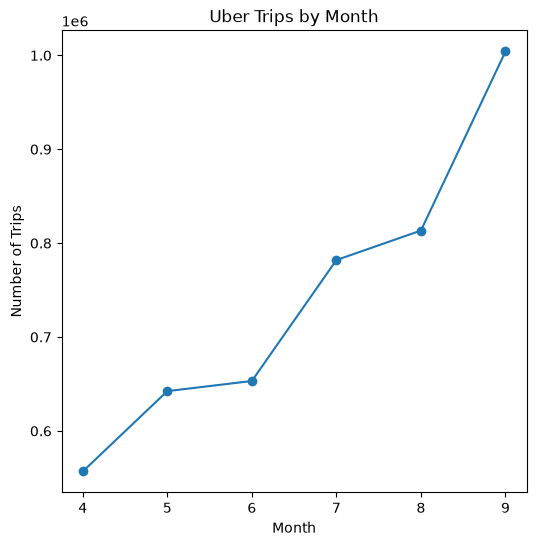

In [55]:
# monthly trips analysis
monthly_trips = merged_df["Month"].value_counts().sort_index()

plt.figure(figsize=(6,6))

plt.plot(
    monthly_trips.index,
    monthly_trips.values,
    marker="o"
)

plt.title("Uber Trips by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.xticks([4,5,6,7,8,9])

plt.show()

In [ ]:
### Insight
Uber trip volume shows an overall increasing trend from April to September 2014.
September recorded the highest number of trips, while April recorded the lowest.

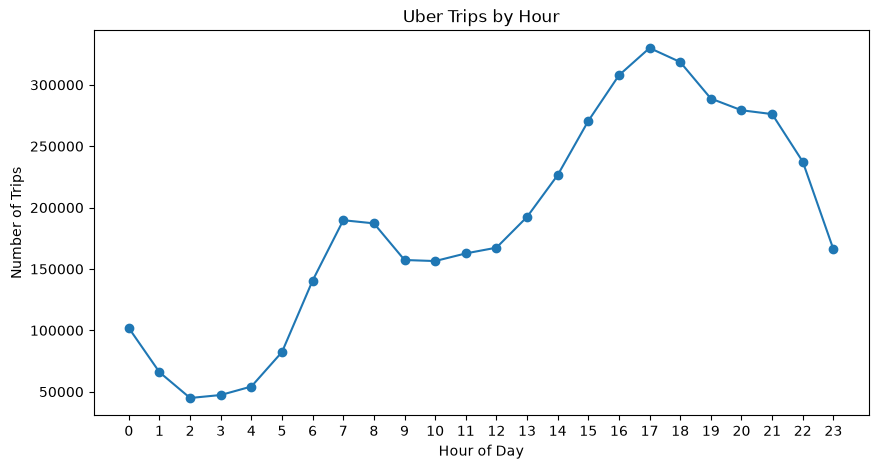

In [39]:
#hourly trips
hourly_trips = merged_df["Hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    hourly_trips.index,
    hourly_trips.values,
    marker="o"
)

plt.title("Uber Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0,24))

plt.show()

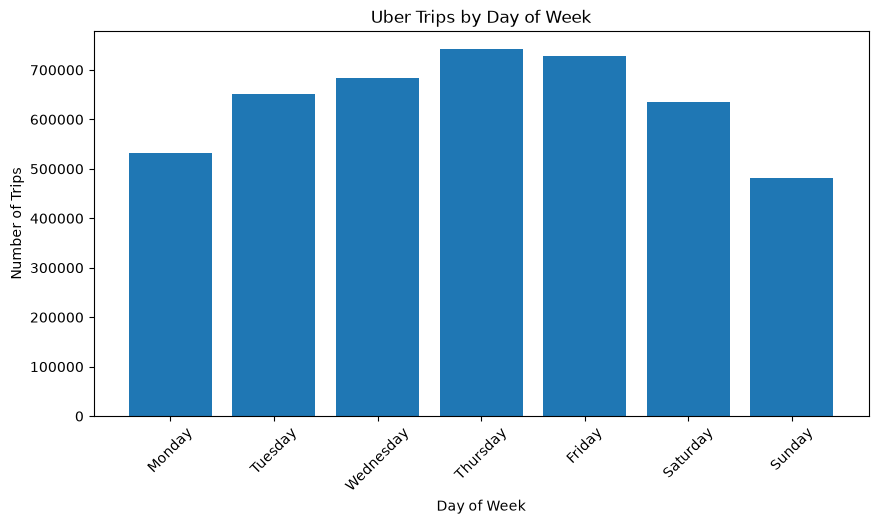

In [40]:
#Trips by Day of Week
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_trips = merged_df["Day_of_week"].value_counts().reindex(day_order)
plt.figure(figsize=(10,5))

plt.bar(
    daily_trips.index,
    daily_trips.values
)

plt.title("Uber Trips by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.show()

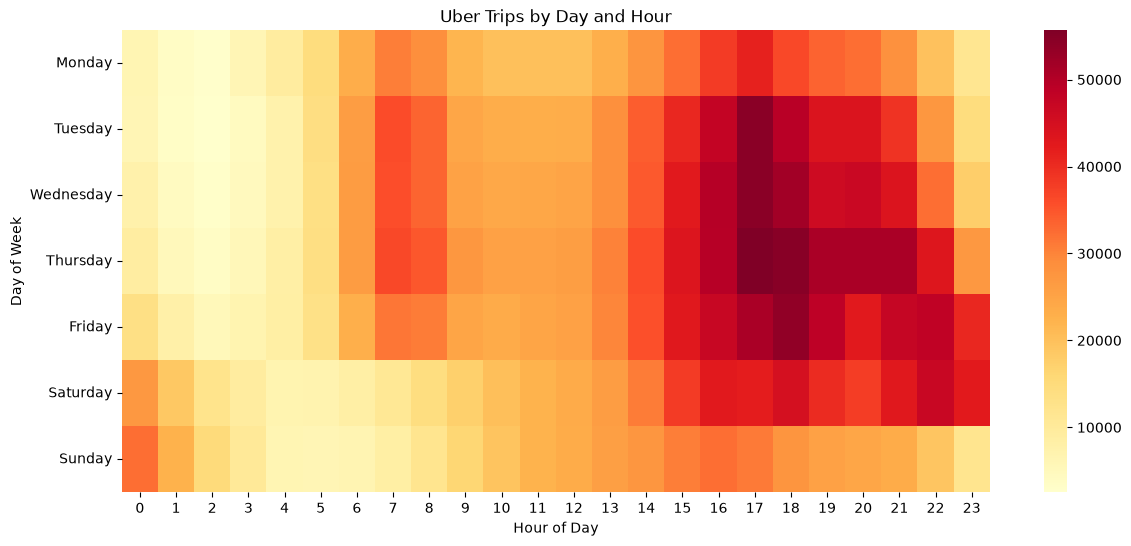

In [41]:
#Day × Hour Analysis
day_hour = pd.crosstab(
    merged_df["Day_of_week"],
    merged_df["Hour"]
)

day_hour = day_hour.reindex(day_order)
import seaborn as sns
plt.figure(figsize=(14,6))

sns.heatmap(
    day_hour,
    cmap="YlOrRd"
)

plt.title("Uber Trips by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

Base
B02617    1417983
B02598    1379578
B02682    1198901
B02764     254931
B02512     200353
Name: count, dtype: int64


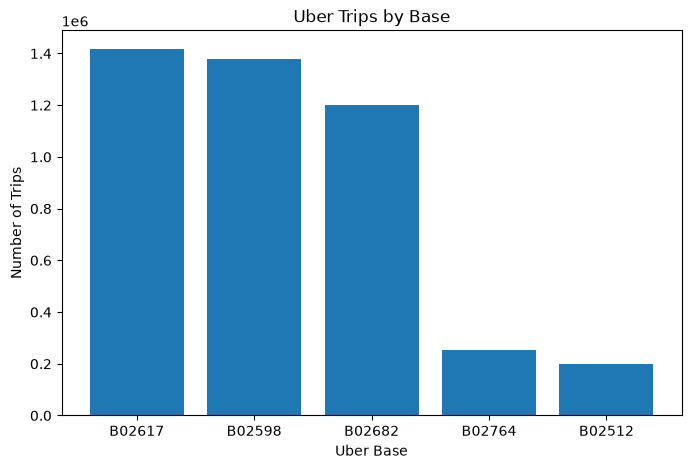

In [42]:
#Base Analysis
base_trips = merged_df["Base"].value_counts()

print(base_trips)
plt.figure(figsize=(8,5))

plt.bar(
    base_trips.index,
    base_trips.values
)

plt.title("Uber Trips by Base")
plt.xlabel("Uber Base")
plt.ylabel("Number of Trips")

plt.show()

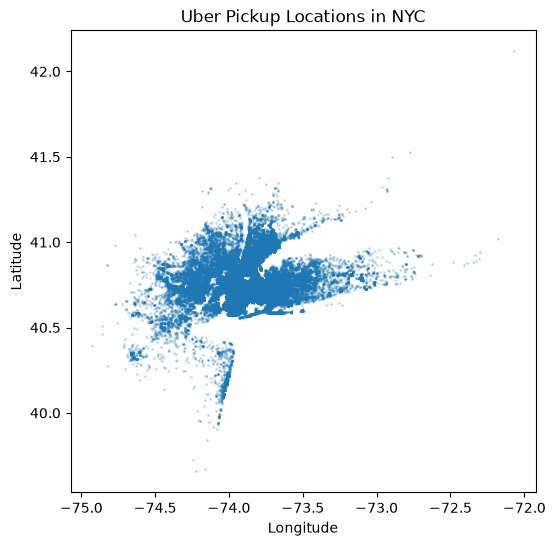

In [54]:
#Geographic Analysis.
plt.figure(figsize=(6,6))

plt.scatter(
    merged_df["Lon"],
    merged_df["Lat"],
    s=1,
    alpha=0.2
)

plt.title("Uber Pickup Locations in NYC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [44]:
#Pickup Density
merged_df["Lat_bin"] = merged_df["Lat"].round(2)
merged_df["Lon_bin"] = merged_df["Lon"].round(2)

In [45]:
#Count trips in each area
location_trips = (
    merged_df.groupby(["Lat_bin", "Lon_bin"])
    .size()
    .reset_index(name="Trips")
)

In [46]:
#busiest areas
top_locations = location_trips.sort_values(
    "Trips",
    ascending=False
).head(10)

print(top_locations)

      Lat_bin  Lon_bin   Trips
2441    40.76   -73.98  223068
2442    40.76   -73.97  212040
2197    40.74   -73.99  189105
2317    40.75   -73.99  169186
1949    40.72   -74.00  164785
2318    40.75   -73.98  156922
2070    40.73   -74.00  155647
2071    40.73   -73.99  139016
2196    40.74   -74.00  133336
2440    40.76   -73.99  118727


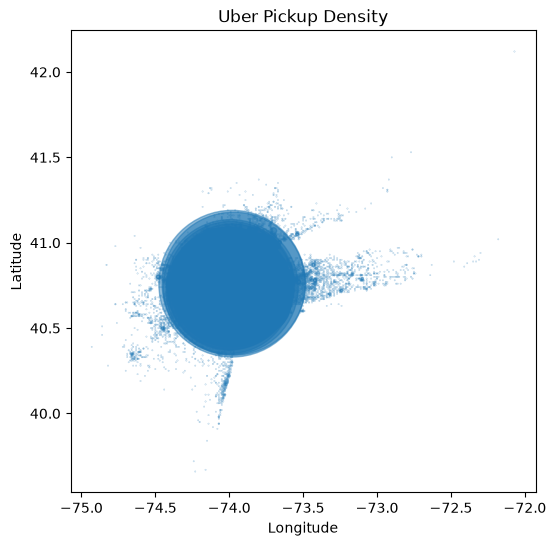

In [53]:
plt.figure(figsize=(6,6))

plt.scatter(
    location_trips["Lon_bin"],
    location_trips["Lat_bin"],
    s=location_trips["Trips"] / 20,
    alpha=0.5
)

plt.title("Uber Pickup Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [48]:
#KPI Summary
kpi_summary = {
    "Total Trips": len(merged_df),
    "Total Uber Bases": merged_df["Base"].nunique(),
    "Busiest Month": monthly_trips.idxmax(),
    "Trips in Busiest Month": monthly_trips.max(),
    "Peak Hour": hourly_trips.idxmax(),
    "Trips in Peak Hour": hourly_trips.max(),
    "Busiest Day": daily_trips.idxmax(),
    "Trips on Busiest Day": daily_trips.max()
}

kpi_df = pd.DataFrame(
    kpi_summary.items(),
    columns=["KPI", "Value"]
)

kpi_df

,KPI,Value
0,Total Trips,4451746
1,Total Uber Bases,5
2,Busiest Month,9
3,Trips in Busiest Month,1004099
4,Peak Hour,17
5,Trips in Peak Hour,330024
6,Busiest Day,Thursday
7,Trips on Busiest Day,741372


### Key Insights

### 1. Overall Trip Volume
A total of 4.45 million Uber trip records were analyzed across
April to September 2014 after removing exact duplicate records.

### 2. Monthly Demand
Recorded trip volume increased substantially from April to September,
with September having the highest trip volume at 1,004,099 trips.

### 3. Peak Hour
The highest recorded hourly trip volume occurred at 5 PM, with
330,024 trips. Trip activity generally increased during the day
and was higher during the afternoon and evening period.

### 4. Day-of-Week Pattern
Thursday recorded the highest number of trips at 741,372, while
Sunday recorded the lowest at 481,158.

### 5. Geographic Distribution
Uber pickups were concentrated in specific geographic areas rather
than being uniformly distributed across the analyzed region.

### 6. Uber Base Distribution
The recorded trips were distributed across 5 Uber bases, with
different levels of trip activity across the bases.

### Business Recommendations

### 1. Peak-Hour Driver Planning
Historical trip patterns can be used to plan driver availability
during high-demand afternoon and evening periods.

### 2. Demand-Based Resource Allocation
Uber can use monthly and daily demand patterns to support
operational planning and resource allocation.

### 3. Geographic Planning
High-density pickup areas can be considered when planning
driver availability and local operations.

### 4. Base-Level Monitoring
Differences in trip activity across Uber bases can be monitored
to understand operational demand distribution.

### Conclusion

This project analyzed 4.45 million Uber trip records from April to
September 2014 using Python and exploratory data analysis.

The analysis examined trip patterns across time, day of week,
Uber bases, and geographic locations. The results showed clear
variation in recorded trip activity across different months,
hours, days, and locations.

The project demonstrates how raw trip-level data can be cleaned,
transformed, analyzed, and converted into meaningful business
insights using Python-based data analytics.